In [1]:
import matplotlib.pyplot as plt
import numpy as np
from lmfit import Minimizer, Parameters
import sys
import pylab as py
import pandas as pd
import csv
import matplotlib.dates as mdates
from scipy import optimize, stats
from importlib import reload
import DataAnalysis.basic_functions as bf
import DataAnalysis.mod_expo_fit_functions as modf
import DataAnalysis.bi_fit_functions as bi_fit
import DataAnalysis.pulser_fit_functions as pf

sys.path.append('/Users/arleeshelby/ManitobaWork_1374/pyNab/src')
import nabPy as Nab

In [2]:
run_numbers = list(np.arange(8622,8633)) + list(np.arange(8635,8638)) + list(np.arange(8643,8660)) + list(np.arange(8681,8695)) + list(np.arange(8696,8700)) + list(np.arange(8704,8714)) + list(np.arange(8715,8722)) + list(np.arange(8824,8833))+list(np.arange(8834,8836)) + list(np.arange(8837,8851)) + list(np.arange(8853,8866))


In [3]:
UDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='UDET')
LDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='LDET')

In [4]:
UDETenergy_pulser = bf.get_energy(run_numbers,UDETdata_pulser)
LDETenergy_pulser = bf.get_energy(run_numbers,LDETdata_pulser)

In [5]:
bin_edges_pulser = UDETdata_pulser[8622]['bin_edges']['0']['60']
bin_edges_pulser112 = UDETdata_pulser[8622]['bin_edges']['0']['pulser BC 112']

In [6]:
LDETpixels = ['1009','1010','1011','1012','1013','1017','1018','1019','1020','1021','1022','1023','1026','1027','1028','1029','1030','1031','1032',
               '1033','1037','1038','1039','1040','1041','1042','1043','1044','1047','1048','1049','1050','1051','1052','1053','1054','1055','1056',
               '1060','1061','1062','1062','1063','1064','1065','1066','1067','1068','1069','1072','1073','1074','1075','1076','1077','1078','1079','1080',
               '1081','1084','1085','1086','1087','1088','1089','1090','1091','1092','1094','1095','1096','1098','1099','1100','1101','1102','1105',
               '1107','1108','1109','1111','1116','1117']

In [7]:
UDETpixels = ['9','11','12','17','19','20','21','26','27','28','29','30','31','32','37','38','39','40','41','42','43','47','48','49','50','51','52',
          '53','54','55','60','61','62','63','64','65','66','67','72','73','74','75','76','77','78','79','84','85','86','87','88','89','90','91',
          '94','95','96','97','98','99','100','101','102','105','106','107','108','109','110','115','117']

In [8]:
UDETpulser_df = bf.get_results_df(pf.get_pulser_results, UDETenergy_pulser, bin_edges_pulser, UDETpixels, run_numbers, plot=False,pulser=True,BC=112,raw_pulser_bin_edges=bin_edges_pulser112,detector_type='UDET')



In [9]:
LDETpulser_df = bf.get_results_df(pf.get_pulser_results, LDETenergy_pulser, bin_edges_pulser, LDETpixels, run_numbers, plot=False,pulser=True,BC=223,raw_pulser_bin_edges=bin_edges_pulser112,detector_type='LDET')

no errors found for run: 8837, pixel: pulser BC 223
no errors found for run: 8839, pixel: pulser BC 223
no errors found for run: 8853, pixel: pulser BC 223
no errors found for run: 8861, pixel: pulser BC 223


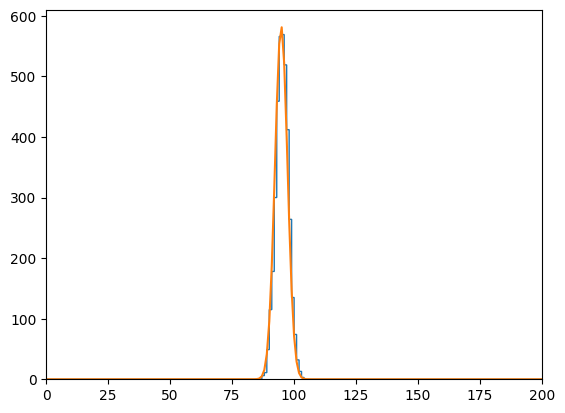

In [10]:
params = Parameters()

params.add('num_peaks',value=1)
params.add('amp1',value=UDETpulser_df['9'][8631][0]['amp1']['value'])
params.add('cen1',value=UDETpulser_df['9'][8631][0]['cen1']['value'])
params.add('sig1',value=UDETpulser_df['9'][8631][0]['sig1']['value'])

x = bin_edges_pulser
plt.stairs(UDETenergy_pulser[8631]['9'],x)
plt.plot(x,pf.pulser_model(params,x))
plt.xlim(0,200)
plt.show()

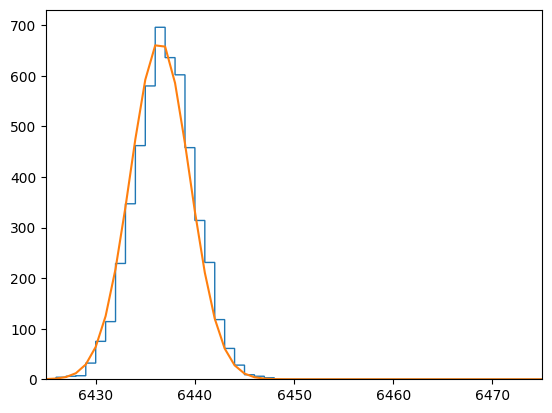

In [13]:
params = Parameters()

params.add('num_peaks',value=1)
params.add('amp1',value=UDETpulser_df['60'][8622][0]['amp1']['value'])
params.add('cen1',value=UDETpulser_df['60'][8622][0]['cen1']['value'])
params.add('sig1',value=UDETpulser_df['60'][8622][0]['sig1']['value'])

x = bin_edges_pulser
plt.stairs(UDETenergy_pulser[8622]['60'],x)
plt.plot(x,pf.pulser_model(params,x))
plt.xlim(6425,6475)
plt.show()

9 8631
9 8839
91 8626
91 8635
91 8685
91 8692
91 8837
91 8862
95 8718
95 8830
96 8652
96 8706
96 8850


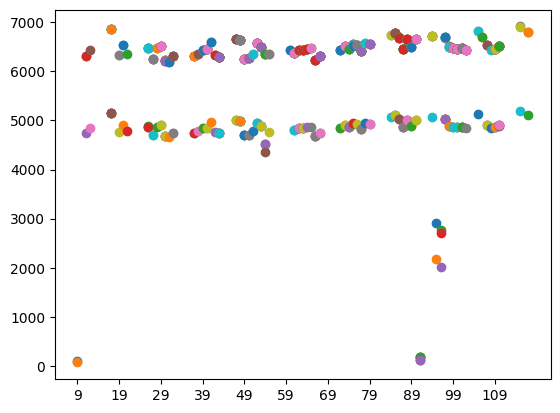

In [50]:
keys = list(UDETpulser_df.keys())
for i in range(len(keys)-1):
    runs = list(UDETpulser_df[keys[i]].keys())
    for j in range(len(runs)):
        plt.scatter(int(keys[i]),UDETpulser_df[keys[i]][runs[j]][0]['cen1']['value'])
        if UDETpulser_df[keys[i]][runs[j]][0]['cen1']['value']<4000:
            print(keys[i],runs[j])
plt.xticks(range(int(keys[0]),int(keys[-2]),10))
plt.show()

In [54]:
UDETpulser_df['9'].keys()

dict_keys([8631, 8839])

1017 8719
1017 8829
1021 8635
1021 8636
1021 8652
1021 8692
1021 8693
1021 8706
1021 8718
1021 8719
1021 8829
1021 8830
1021 8850
1021 8861
1021 8862
1028 8623
1028 8644
1028 8682
1028 8697
1028 8835
1028 8863
1032 8623
1032 8629
1032 8644
1032 8649
1032 8682
1032 8688
1032 8697
1032 8713
1032 8716
1032 8717
1032 8825
1032 8835
1032 8841
1032 8845
1032 8863
1032 8864
1043 8626
1043 8630
1043 8644
1043 8648
1043 8651
1043 8685
1043 8689
1043 8697
1043 8705
1043 8715
1043 8837
1043 8840
1043 8846
1043 8849
1043 8863
1054 8828
1054 8834
1054 8840
1054 8847
1054 8862
1054 8863


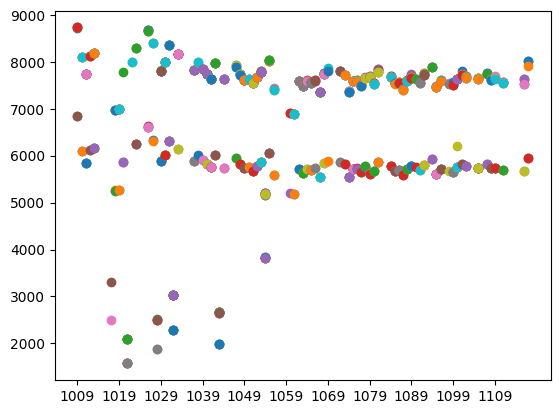

In [12]:
keys = list(LDETpulser_df.keys())
for i in range(len(keys)-1):
    runs = list(LDETpulser_df[keys[i]].keys())
    for j in range(len(runs)):
        plt.scatter(int(keys[i]),LDETpulser_df[keys[i]][runs[j]][0]['cen1']['value'])
        if LDETpulser_df[keys[i]][runs[j]][0]['cen1']['value']<4000:
            print(keys[i],runs[j])
plt.xticks(range(int(keys[0]),int(keys[-2]),10))
plt.show()